In [45]:
import pandas as pd
import numpy as np

In [46]:
pred_df = pd.read_csv('/home/ethan2/GrowthCurve/data/inference/inference_output_predictions.csv')

In [47]:
print(pred_df['Concentration'].value_counts())

Concentration
1.2    14040294
7.9    14040294
Name: count, dtype: int64


In [48]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd

def plot_od_distributions_by_timepoint(
    pred_df: pd.DataFrame,
    concentration: float,
    bins: int = 100,
    clip_range: tuple | None = None,
    y_mode: str = "count",       # "count" or "density"
    fixed_ylim_density: tuple = (0.0, 0.4),
    max_count: float | None = None,  # cap for y-axis when using counts
):
    """
    Plot Pred_OD distributions for each Timepoint (2x3 grid) at a given Concentration.

    Args:
        pred_df: DataFrame with ['Concentration','Timepoint','Pred_OD'].
        concentration: value to filter.
        bins: number of histogram bins.
        clip_range: optional (min,max) to clip Pred_OD.
        y_mode: 'density' (normalized) or 'count' (absolute frequency).
        fixed_ylim_density: (min, max) for density plots.
        max_count: if provided, caps y-axis at this count for all subplots.
    """
    # Filter by concentration
    df_sub = pred_df[pred_df["Concentration"] == concentration].copy()
    if df_sub.empty:
        print(f"⚠️ No samples found for concentration {concentration}")
        return

    if clip_range is not None:
        df_sub["Pred_OD"] = df_sub["Pred_OD"].clip(*clip_range)

    # Sort timepoints
    timepoints = sorted(df_sub["Timepoint"].unique())

    # If using count and no max_count, find shared maximum count
    global_ymax = None
    if y_mode == "count" and max_count is None:
        ymaxs = []
        for t in timepoints:
            counts, _ = np.histogram(
                df_sub.loc[df_sub["Timepoint"] == t, "Pred_OD"],
                bins=bins,
                range=(0, 1.2),
            )
            ymaxs.append(counts.max())
        global_ymax = max(ymaxs)

    fig, axes = plt.subplots(2, 3, figsize=(15, 8), sharey=True)
    axes = axes.flatten()

    for ax, t in zip(axes, timepoints):
        subset = df_sub.loc[df_sub["Timepoint"] == t, "Pred_OD"]

        stat = "density" if y_mode == "density" else "count"
        sns.histplot(subset, bins=bins, kde=True, stat=stat, color="steelblue", ax=ax)

        ax.set_xlim(0, 1.2)
        if y_mode == "density":
            ax.set_ylim(*fixed_ylim_density)
            ax.set_ylabel("Density")
        else:
            # Use capped or computed max count
            ymax = max_count if max_count is not None else global_ymax
            ax.set_ylim(0, ymax * 1.05)
            ax.set_ylabel("Count")

        ax.set_title(f"Timepoint {t} h", fontsize=11)
        ax.set_xlabel("Predicted OD")
        ax.grid(False)

    # Remove unused axes
    for k in range(len(timepoints), len(axes)):
        fig.delaxes(axes[k])

    plt.suptitle(
        f"Predicted OD Distributions at Concentration = {concentration} ({y_mode})",
        fontsize=14,
        y=1.02,
    )
    plt.tight_layout()
    plt.show()


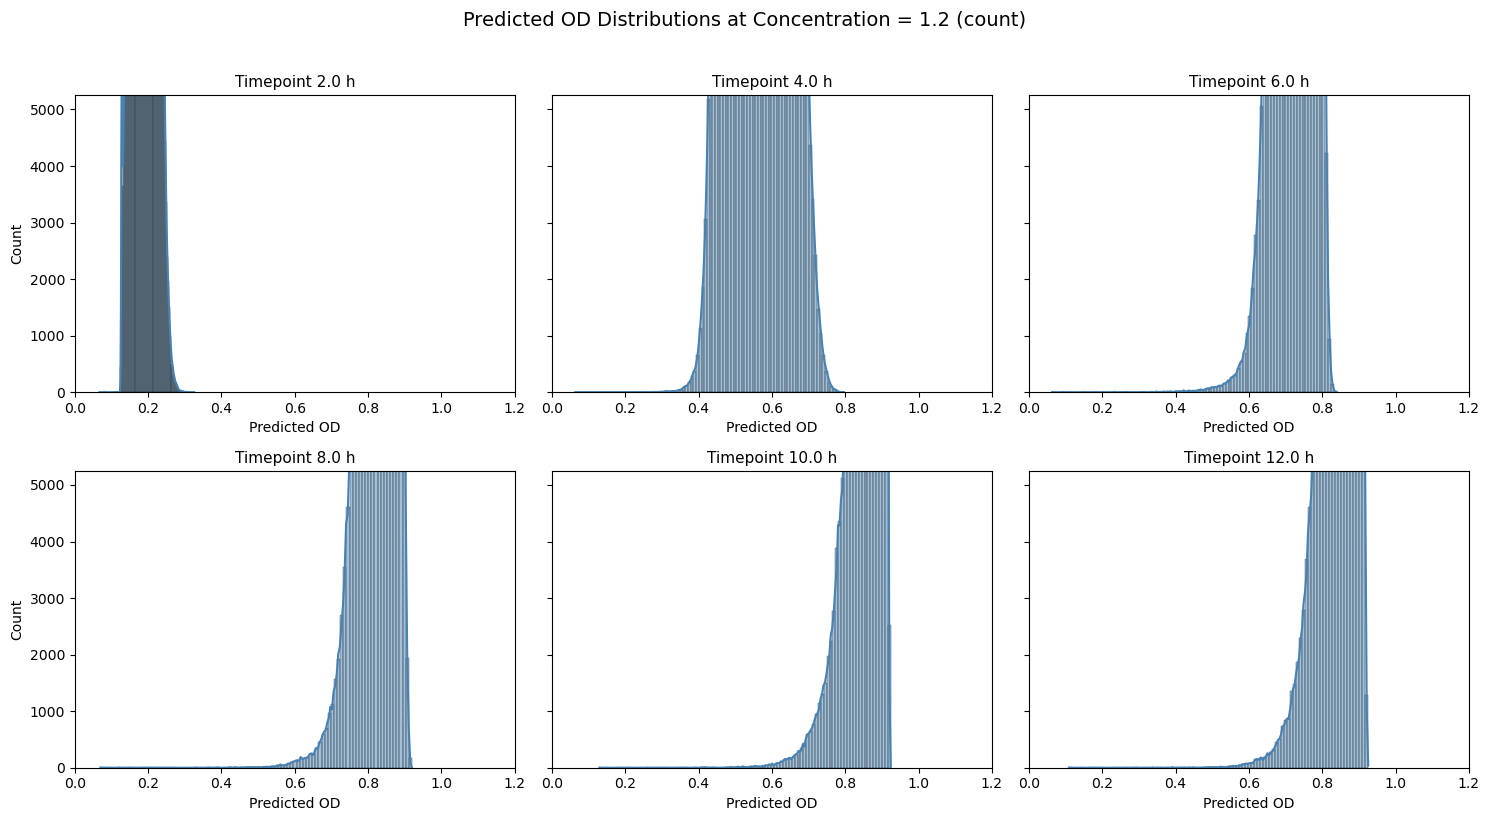

In [27]:
plot_od_distributions_by_timepoint(
    pred_df,
    concentration=1.2,
    y_mode="count",
    max_count=5000,  # cap y-axis
)

In [34]:
pred_df[(pred_df['Concentration'] == 1.2) & (pred_df['Timepoint'] == 12) & (pred_df['Pred_OD'] >0.80)]

,Compound,SMILES,Concentration,Timepoint,Pred_OD,Pred_ProbActive
11700245,Z104497392,SC1=NCCN1,1.2,12.0,0.9185,0.018160
11700246,Z104495272,NC=1C=CN=CC1,1.2,12.0,0.9140,0.008950
11700247,Z1203730895,CC1CNC(=O)N1,1.2,12.0,0.9165,0.009860
11700248,Z1569708704,Cl.NC=1CCNN1,1.2,12.0,0.9160,0.025860
11700249,Z1868316810,C#CC=1C=CNN1,1.2,12.0,0.9175,0.010210
...,...,...,...,...,...,...
14040289,Z8999761509,O=C(O)C(F)(F)F.CC(C)C[C@@H](NC(=O)C1=NC=CC2=CC...,1.2,12.0,0.8896,0.019240
14040290,Z9124290161,O=C(O)C(F)(F)F.CC1CN(CCCNS(=O)(=O)CCN2CCOC2=O)...,1.2,12.0,0.9004,0.030440
14040291,Z9183998842,O=C(O)C(F)(F)F.CCC1=CN=C(CN2CCCC2(C)C(=O)O)O1,1.2,12.0,0.8857,0.027590
14040292,Z9322864217,O=C(O)C(F)(F)F.C1=NN=C(NCC=2C=CC(=CC2)OCC3CCCO...,1.2,12.0,0.8950,0.013740


In [31]:
pred_df[(pred_df['Concentration'] == 1.2) & (pred_df['Timepoint'] == 6) & (pred_df['Pred_OD'] < 0.20)]

,Compound,SMILES,Concentration,Timepoint,Pred_OD,Pred_ProbActive
4722128,Z19833666,CC=1C=CC2=C(Cl)C=C(Cl)C(OCC#N)=C2N1,1.2,6.0,0.18500,0.9155
4778027,Z728800606,Cl.CN(C)[C@@H]1C(O)=C(C(N)=O)C(=O)[C@@]2(O)C(O...,1.2,6.0,0.15160,0.9220
4790073,Z57825347,OC1=C(I)C=C(I)C2=CC=CN=C12,1.2,6.0,0.06420,0.9414
4801161,Z56756436,COC=1C=CC=CC1OC=2C(F)=C(F)C(OC=3C=CC=CC3OC)=C(...,1.2,6.0,0.14970,0.9253
4843850,Z754926486,CO[C@H]1C=CO[C@@]2(C)OC=3C(C)=C(O)C=4C(=O)C(NC...,1.2,6.0,0.13460,0.9190
4863727,Z600416600,N#CC=1C=CC(OC=2C=CC=CC2O)=C(F)C1,1.2,6.0,0.09120,0.9340
4960052,Z2144222809,CN(C)[C@@H]1C(O)=C(C(N)=O)C(=O)[C@@]2(O)C(O)=C...,1.2,6.0,0.17020,0.9150
4999049,Z1723933592,O=S(=O)(OC=1C(Cl)=CC(Cl)=C2C=CC=NC12)C3=CC=C(C...,1.2,6.0,0.18040,0.9220
5037515,Z2791720087,O.Cl.Cl.CCO.C[C@H]1C2=CC=CC(O)=C2C(=O)C3=C(O)[...,1.2,6.0,0.18200,0.9070
5118878,Z104483432,OC1=C(I)C=C(Cl)C2=CC=CN=C12,1.2,6.0,0.09910,0.9346


In [49]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

def plot_predicted_od_by_compound(
    pred_df: pd.DataFrame,
    compound: str,
    save_path: str | None = None,
):
    """
    Plot predicted OD values across timepoints for a given compound,
    creating one subplot per concentration.

    Args:
        pred_df: DataFrame with ['Compound', 'Concentration', 'Timepoint', 'Pred_OD'].
        compound: The compound name (string) to filter on.
        save_path: Optional path to save the figure.
    """
    df_sub = pred_df[pred_df["Compound"] == compound].copy()
    if df_sub.empty:
        print(f"⚠️ No predictions found for compound '{compound}'")
        return

    concentrations = sorted(df_sub["Concentration"].unique())
    n_conc = len(concentrations)

    # Create figure grid — 2 columns, auto rows
    ncols = 2
    nrows = int(np.ceil(n_conc / ncols))

    fig, axes = plt.subplots(nrows, ncols, figsize=(10, 4 * nrows), sharey=True)
    axes = np.array(axes).reshape(-1)  # flatten for indexing

    for i, c in enumerate(concentrations):
        ax = axes[i]
        subset = df_sub[df_sub["Concentration"] == c].sort_values("Timepoint")

        sns.lineplot(
            data=subset,
            x="Timepoint",
            y="Pred_OD",
            marker="o",
            color="steelblue",
            ax=ax,
        )

        ax.set_title(f"Concentration = {c}", fontsize=11)
        ax.set_xlabel("Timepoint (h)")
        ax.set_ylabel("Predicted OD")
        ax.set_xlim(df_sub["Timepoint"].min(), df_sub["Timepoint"].max())
        ax.set_ylim(0, 1.2)
        ax.grid(True, linestyle="--", alpha=0.4)

    # Remove unused subplots if there are any
    for j in range(n_conc, len(axes)):
        fig.delaxes(axes[j])

    plt.suptitle(f"Predicted OD over Time for {compound}", fontsize=14, y=1.02)
    plt.tight_layout()

    if save_path:
        plt.savefig(save_path, bbox_inches="tight", dpi=300)
        print(f"💾 Saved figure → {save_path}")
    plt.show()


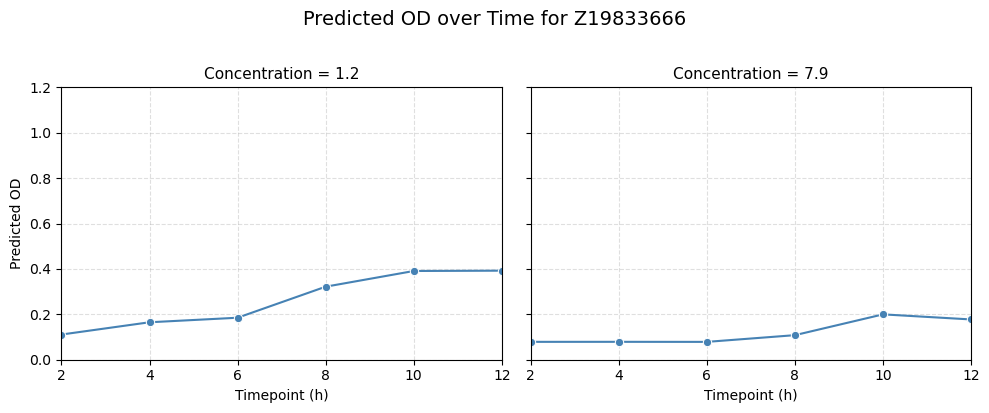

In [50]:
plot_predicted_od_by_compound(
    pred_df,
    compound="Z19833666",   # or whatever compound ID / name
)

In [41]:
pred_df['Concentration'].value_counts()

Concentration
1.2    14040294
Name: count, dtype: int64

In [40]:
pred_df[pred_df['Compound']=='Z19833666']

,Compound,SMILES,Concentration,Timepoint,Pred_OD,Pred_ProbActive
42030,Z19833666,CC=1C=CC2=C(Cl)C=C(Cl)C(OCC#N)=C2N1,1.2,2.0,0.1109,0.3140
2382079,Z19833666,CC=1C=CC2=C(Cl)C=C(Cl)C(OCC#N)=C2N1,1.2,4.0,0.1650,0.8926
4722128,Z19833666,CC=1C=CC2=C(Cl)C=C(Cl)C(OCC#N)=C2N1,1.2,6.0,0.1850,0.9155
7062177,Z19833666,CC=1C=CC2=C(Cl)C=C(Cl)C(OCC#N)=C2N1,1.2,8.0,0.3218,0.9290
9402226,Z19833666,CC=1C=CC2=C(Cl)C=C(Cl)C(OCC#N)=C2N1,1.2,10.0,0.3909,0.9326
11742275,Z19833666,CC=1C=CC2=C(Cl)C=C(Cl)C(OCC#N)=C2N1,1.2,12.0,0.3923,0.9280


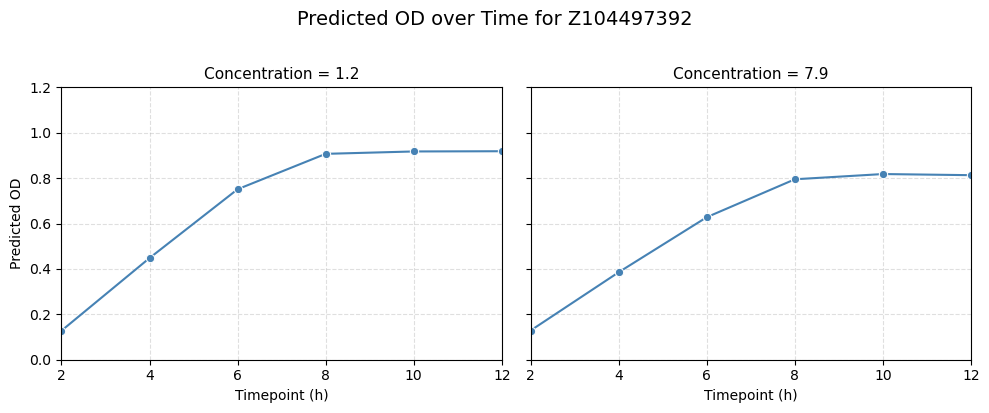

In [51]:


plot_predicted_od_by_compound(
    pred_df,
    compound="Z104497392",   # or whatever compound ID / name
)